In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [71]:
!unzip '/content/drive/MyDrive/Group A.zip'

Streaming output truncated to the last 5000 lines.
  inflating: Group A/Non_Isolated/AHCR_00037_Non_Isolated_62.jpg  
  inflating: Group A/Non_Isolated/AHCR_00037_Non_Isolated_63.jpg  
  inflating: Group A/Non_Isolated/AHCR_00038_Non_Isolated_54.jpg  
  inflating: Group A/Non_Isolated/AHCR_00038_Non_Isolated_55.jpg  
  inflating: Group A/Non_Isolated/AHCR_00038_Non_Isolated_62.jpg  
  inflating: Group A/Non_Isolated/AHCR_00038_Non_Isolated_63.jpg  
  inflating: Group A/Non_Isolated/AHCR_00039_Non_Isolated_54.jpg  
  inflating: Group A/Non_Isolated/AHCR_00039_Non_Isolated_55.jpg  
  inflating: Group A/Non_Isolated/AHCR_00039_Non_Isolated_62.jpg  
  inflating: Group A/Non_Isolated/AHCR_00039_Non_Isolated_63.jpg  
  inflating: Group A/Non_Isolated/AHCR_00040_Non_Isolated_54.jpg  
  inflating: Group A/Non_Isolated/AHCR_00040_Non_Isolated_55.jpg  
  inflating: Group A/Non_Isolated/AHCR_00040_Non_Isolated_62.jpg  
  inflating: Group A/Non_Isolated/AHCR_00040_Non_Isolated_63.jpg  
  inflating

In [72]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group A"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))  

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path): 
                img_path = os.path.join(group_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 5982, Testing samples: 1496
Number of classes: 16


In [74]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [75]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


374/374 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.0750 - loss: 2.7956 - val_accuracy: 0.1631 - val_loss: 2.4942
Epoch 2/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.1959 - loss: 2.4435 - val_accuracy: 0.5007 - val_loss: 1.6055
Epoch 3/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.3706 - loss: 1.8694 - val_accuracy: 0.6203 - val_loss: 1.1825
Epoch 4/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.4776 - loss: 1.5155 - val_accuracy: 0.6678 - val_loss: 1.0524
Epoch 5/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.5328 - loss: 1.3623 - val_accuracy: 0.6925 - val_loss: 0.9666
Epoch 6/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.5607 - loss: 1.3151 - val_accuracy: 0.7152 - val_loss: 0.8567
Epoch 7/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.6060 - loss: 1.1810 - val_accuracy: 0.7386 - val_loss: 0.7995
Epoch 8/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.6185 - loss: 1.1068 - val_accurac

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8403 - loss: 0.4979
Train Accuracy: 76.68%
Test Accuracy: 84.49%


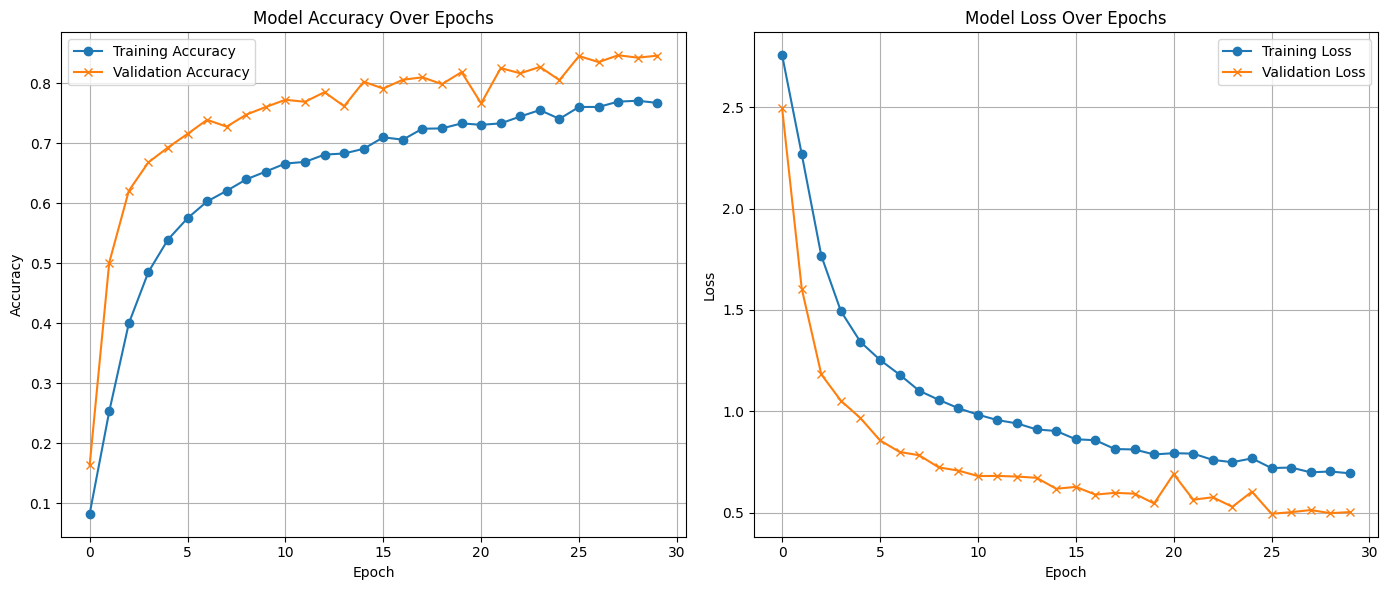

In [77]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


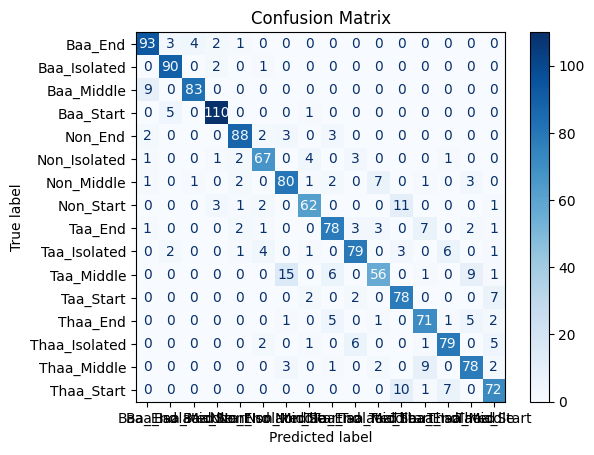

In [78]:

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


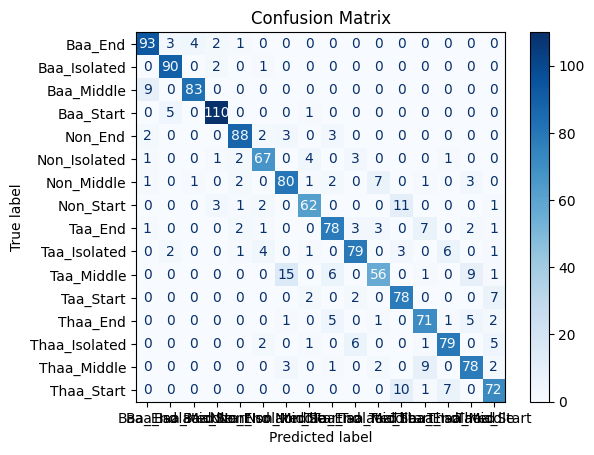

Number of incorrect predictions: 232


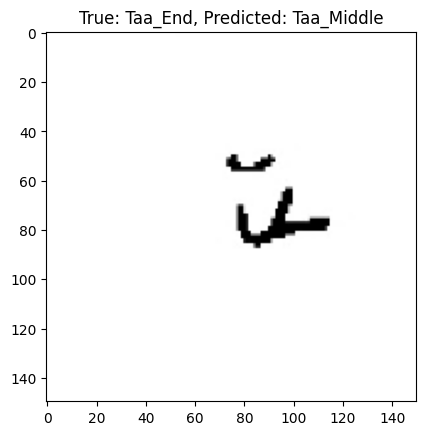

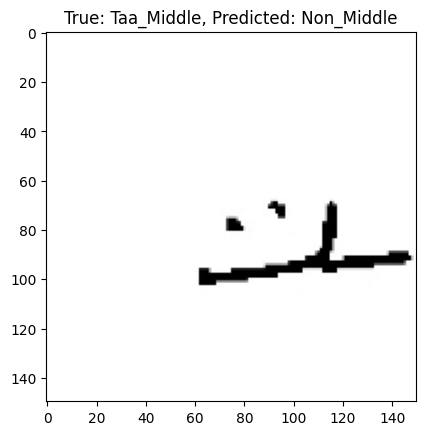

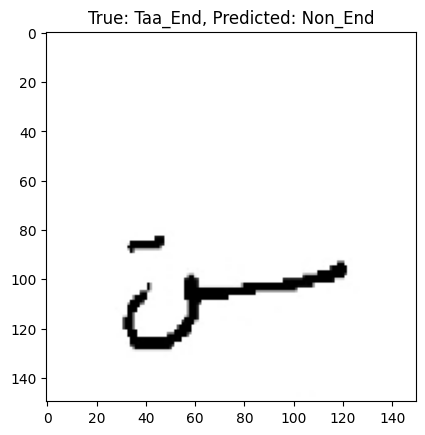

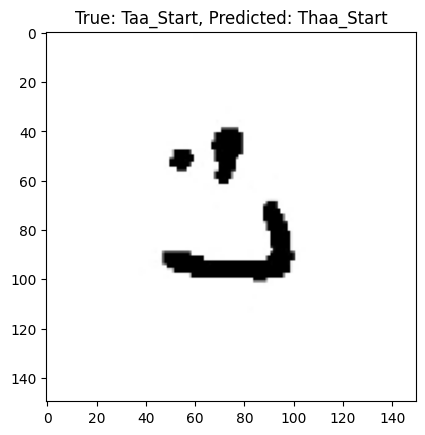

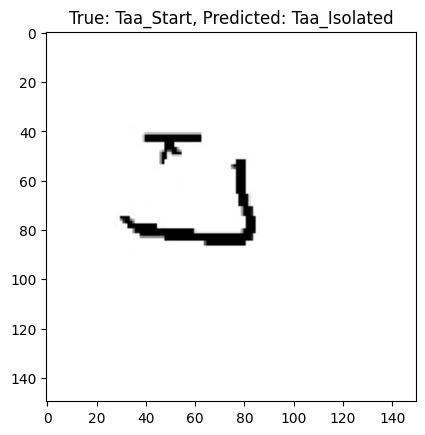

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### decrease dropout and epochs

In [12]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [13]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


374/374 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.0992 - loss: 2.7497 - val_accuracy: 0.3222 - val_loss: 1.9519
Epoch 2/28
374/374 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.3713 - loss: 1.9009 - val_accuracy: 0.5247 - val_loss: 1.4284
Epoch 3/28
374/374 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5282 - loss: 1.4048 - val_accuracy: 0.6444 - val_loss: 1.0573
Epoch 4/28
374/374 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.6232 - loss: 1.1207 - val_accuracy: 0.7126 - val_loss: 0.8710
Epoch 5/28
374/374 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.6508 - loss: 1.0311 - val_accuracy: 0.7039 - val_loss: 0.8896
Epoch 6/28
374/374 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6882 - loss: 0.9304 - val_accuracy: 0.7406 - val_loss: 0.7960
Epoch 7/28
374/374 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7275 - loss: 0.8335 - val_accuracy: 0.7928 - val_loss: 0.6718
Epoch 8/28
374/374 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.7275 - loss: 0.7996 - val_accurac

In [ ]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8427 - loss: 0.5027
Train Accuracy: 81.71%
Test Accuracy: 82.81%


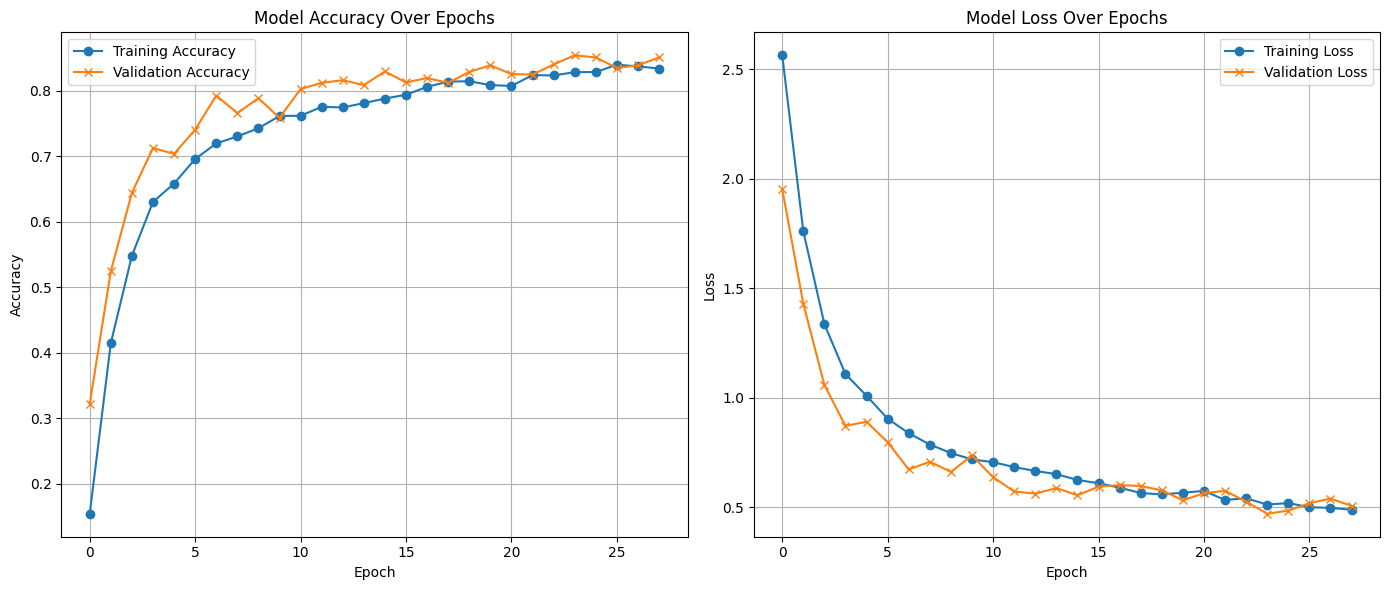

In [15]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


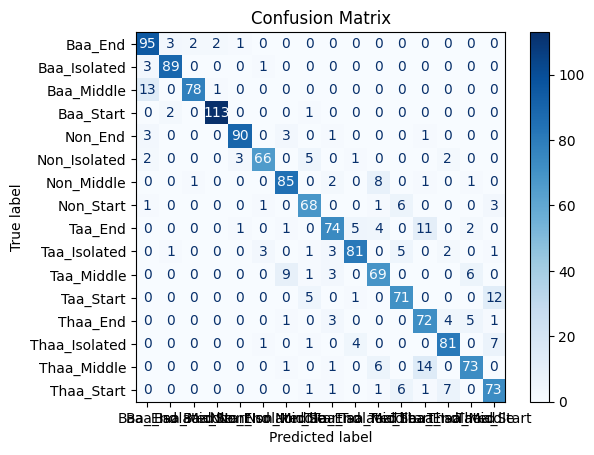

Number of incorrect predictions: 218


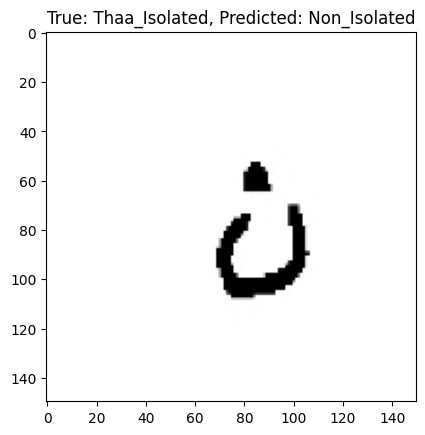

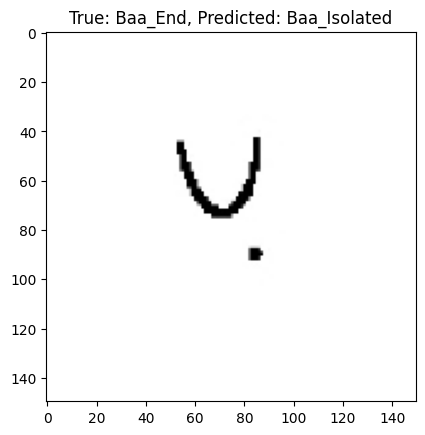

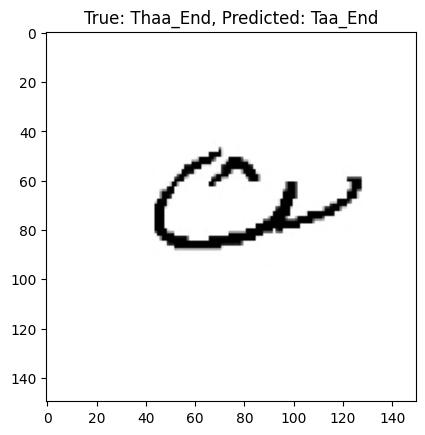

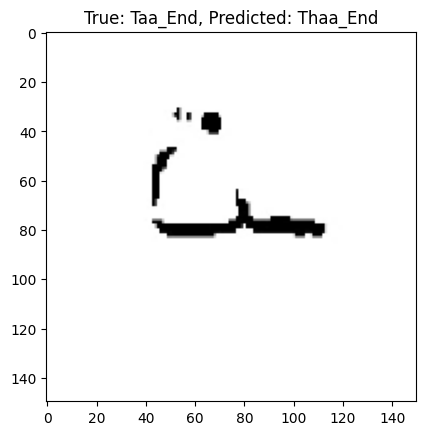

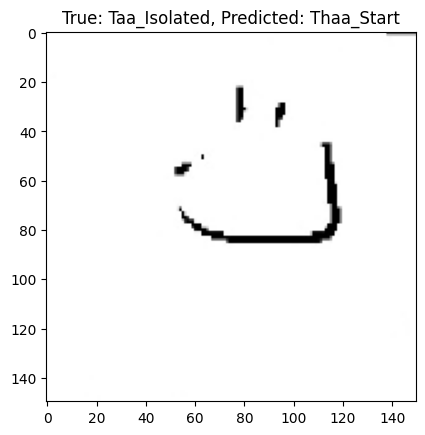

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### decrease epochs and delete dropOut

In [55]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [56]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(125, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [57]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=25,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.0979 - loss: 2.7117 - val_accuracy: 0.4111 - val_loss: 1.7984
Epoch 2/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.3999 - loss: 1.8197 - val_accuracy: 0.5829 - val_loss: 1.2426
Epoch 3/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.5508 - loss: 1.3332 - val_accuracy: 0.6618 - val_loss: 0.9938
Epoch 4/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.6209 - loss: 1.1364 - val_accuracy: 0.6872 - val_loss: 0.9571
Epoch 5/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.6745 - loss: 0.9845 - val_accuracy: 0.7353 - val_loss: 0.7786
Epoch 6/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.7123 - loss: 0.8714 - val_accuracy: 0.7440 - val_loss: 0.7299
Epoch 7/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.7184 - loss: 0.8182 - val_accuracy: 0.7520 - val_loss: 0.7659
Epoch 8/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.7326 - loss: 0.7868 - 

In [58]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8277 - loss: 0.5377
Train Accuracy: 84.72%
Test Accuracy: 83.02%


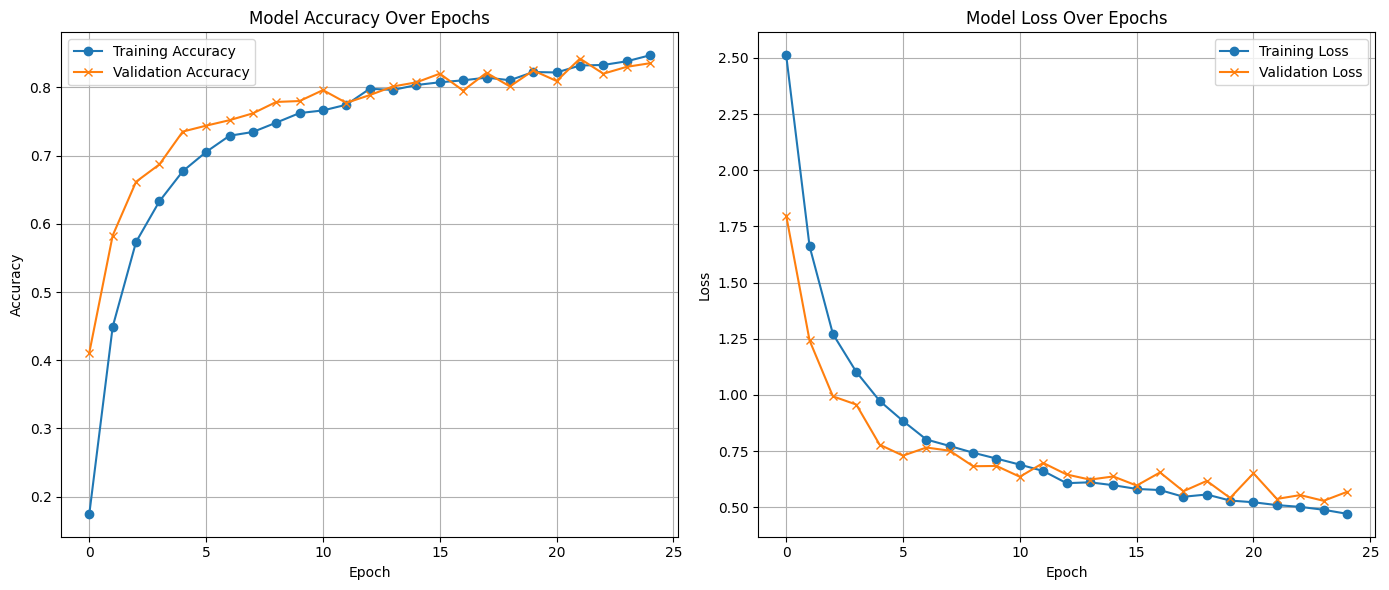

In [59]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


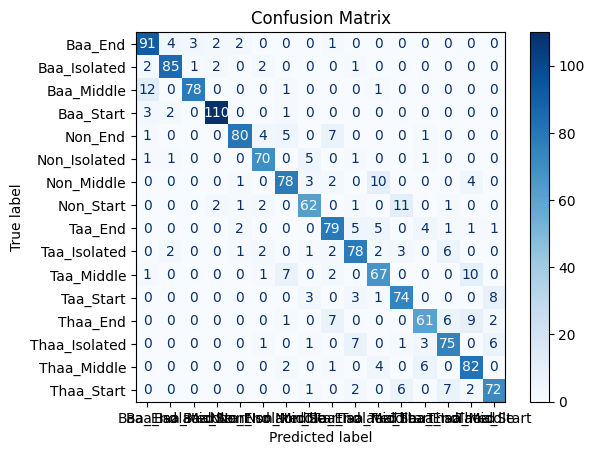

Number of incorrect predictions: 254


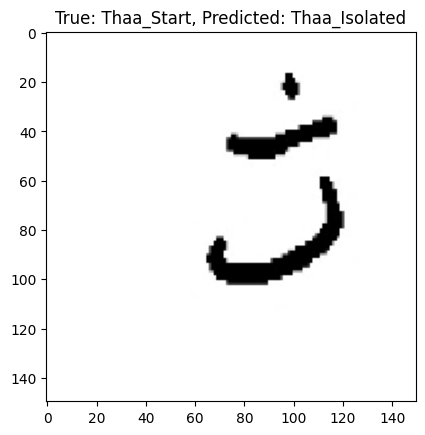

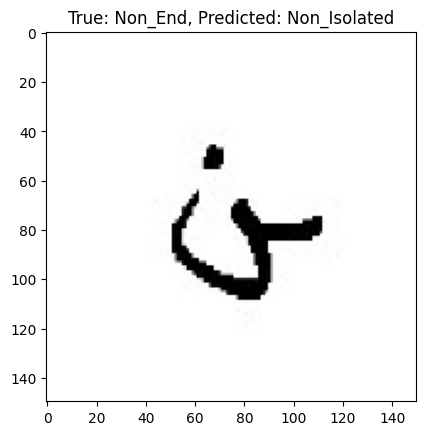

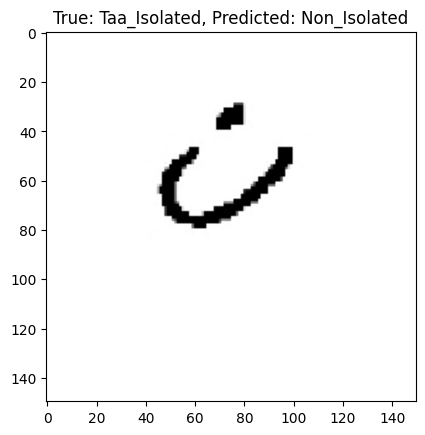

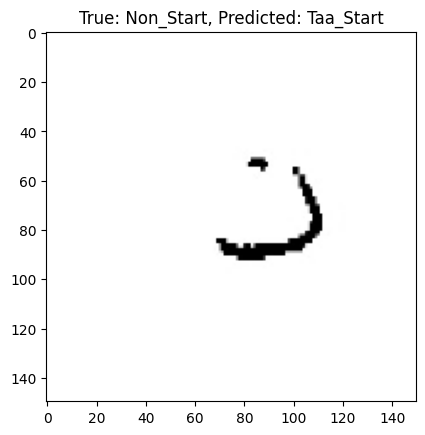

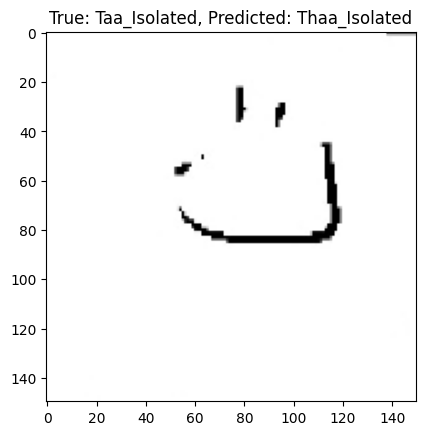

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [61]:
model.save("GrpA.keras")